<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/L8_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8.2 Machine Learning 2 – Artificial Neural Network, Classification

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Training ML model for anomaly detection

Now, you are ready to train ML model. Follow the steps below to create your autoencoder model to predict the anomalous condition of the AFF. In this lab manual, we will use this Colab Notebook. But, you can use this Colab Notefile (ipynb) on your computer using Jupyter Notebook or creating a Python script.

We will reuse the autoencoder training code in [Prelab8.2](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab2.ipynb).

**When you first train the model, please use the given axis, feature, and hyper -parameters to perform Task 2.2. And then, try different combinations.**

### Import Pytorch and relevant Python packages on your Colab session

In [2]:
# Let's check the installed pytorch version
import torch

print('Torch Version is', torch.__version__)

Torch Version is 2.11.0+cpu


In [3]:
import os
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pandas as pd
from scipy import stats, fft

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split

### Load data

First, upload your training data (Normal and Abnormal) which you collected on the last part to this Colab session.

  * Method 1: Upload file on this Colab session (Fast)
  * Method 2: Use the code block below (Slow)
  * Method 3: Mount your Google Drive if your data is in it (Fast)

In [6]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()

Saving 1800abn.csv to 1800abn.csv
Saving 1800n.csv to 1800n.csv


In [14]:
## Loading data using pandas

normal_data_file = "1800n.csv" # normal condition filename: You much change this!
abnormal_data_file = "1800abn.csv" # abnormal condition filename: You much change this!

df_normal = pd.read_csv(normal_data_file) # normal dataframe
df_abnormal = pd.read_csv(abnormal_data_file) # abnormal dataframe

# 👇 [여기 2줄 추가] 각 데이터프레임에 Condition 컬럼 생성
df_normal['Condition'] = 'Normal'
df_abnormal['Condition'] = 'Abnormal'

frames = [df_normal, df_abnormal] # frame list to merge two dataframes into one

df = pd.concat(frames, ignore_index=True) # new concatenated dataframe (ignore_index=True 권장)

df # display dataframe

,Xacc array [m/s2],Yacc array [m/s2],Zacc array [m/s2],Condition
0,0.35181551892465013 0.8720241950716385 -0.0156...,-0.10514192796960725 -0.19853447320683007 -0.5...,9.664183717571218 11.122205123091323 9.4559801...,Normal
1,0.22766995461118011 -0.07745503966527897 0.284...,0.5622588739111084 0.3478084803174948 0.406202...,9.938920725859361 9.466944632899853 10.3845735...,Normal
2,0.2822985098024936 -0.07698833404874195 0.5451...,-0.5311335027141474 0.08624749656820117 0.9759...,9.326624094067439 9.058669018978822 10.2211115...,Normal
3,-0.2747284942865175 -0.31126846094907995 -0.50...,-1.2514534521154435 -0.19930742690081388 0.456...,9.651520603309379 9.506145930826344 10.0508313...,Normal
4,0.12799680280378342 0.09418989370845944 0.7576...,0.2102352037012579 -0.19826570255436643 0.1475...,9.680859800696595 9.344510813264684 9.84107065...,Normal
...,...,...,...,...
325,-0.707923141773565 0.32796580463948355 -0.5883...,0.8557202127675118 0.004763957406556622 -0.054...,10.355310965982023 9.822765103785446 9.3647292...,Abnormal
326,0.2326248753095538 0.3399811132608158 0.447745...,-0.04328162342684338 -0.23213865185385596 -0.0...,8.92117253858982 10.094886539984525 10.0583203...,Abnormal
327,-0.7379567020025656 -0.14415660090842689 0.086...,-0.2177023980593549 -0.09407638531976002 -0.95...,10.078544975845086 9.874210950928813 9.5052917...,Abnormal
328,-0.5534101711186787 -0.36895094108803883 0.415...,-0.45945445640504246 0.099963962223784 -0.8111...,9.52844671605448 9.951129494908788 10.17939441...,Abnormal


### Data Transformation

The strategy to build this model is to select, one by one, data from each axis and access which axis helps the model classify with better accuracy and precision.

Let's start with the X-axis:
Assign the X-axis on the variable AXIS on the code below.

In [12]:
print(df.columns)

Index(['Xacc array [m/s2]', 'Yacc array [m/s2]', 'Zacc array [m/s2]'], dtype='object')


In [15]:
## Data Transformation
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
AXIS = 'Xacc array [m/s2]' # in this case, X-axis acceleration data

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1) # transform space delimited array to each value
ds = df_new.copy() # make ds by copying df

Now, we change the labels 'Normal' and 'Abnormal' into binary notation for the model usage.

In [16]:
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Normal', 'Status'] = 1 # if Condition column is 'Normal', Give 'Status' Column 1
ds.loc[df['Condition'] == 'Abnormal', 'Status'] = 0 # if Condition column is 'Abnormal', Give 'Status' Column 0
if 'Condition' in ds.columns:
    ds.drop('Condition', axis=1, inplace=True)

ds # display ds (dataset)

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,Status
0,0.351816,0.872024,-0.015646,-0.634198,-0.089475,0.507921,-0.053586,-0.099061,-0.763376,0.518848,...,-0.764358,-0.103931,-0.131274,-0.386918,-0.032758,0.606875,0.147628,0.108290,-0.430121,1.0
1,0.227670,-0.077455,0.284378,0.035330,0.139761,0.709646,0.534255,0.660191,-0.909908,-0.188943,...,-0.474761,0.400848,0.175800,-0.380687,0.548297,-0.315319,0.739132,-0.856955,-0.695355,1.0
2,0.282299,-0.076988,0.545130,-0.476805,-0.309971,0.125838,-0.707956,0.371011,0.396222,-1.083883,...,0.085565,-0.145237,-0.466325,-0.448909,0.084507,0.255358,0.122335,-0.086853,-0.854420,1.0
3,-0.274728,-0.311268,-0.508834,-0.014419,0.036371,-0.108205,-0.723432,0.367116,0.115600,0.322386,...,0.269771,-0.073298,0.240176,-0.072167,1.058547,-0.809716,0.332677,-0.493726,-1.128783,1.0
4,0.127997,0.094190,0.757637,-0.627626,-0.055056,0.031168,-0.144260,0.265068,-0.521569,0.290499,...,0.052527,1.149755,0.115709,-0.710713,-0.137039,-0.858637,0.425632,0.437925,-0.423446,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,-0.707923,0.327966,-0.588382,0.231150,-0.086916,-0.344040,-0.057778,0.630251,0.476984,-0.111982,...,0.643833,-0.895971,-0.317812,-0.639876,0.641832,-0.520429,-0.317234,-0.215143,-0.488841,0.0
326,0.232625,0.339981,0.447745,0.642755,-0.358754,-0.485548,-0.221955,0.841644,-0.680883,0.419423,...,-0.542409,-0.514828,1.119853,-0.347510,0.578079,0.041335,0.452388,-1.094285,-0.019276,0.0
327,-0.737957,-0.144157,0.086282,-0.111927,0.263534,0.575332,0.082819,0.099786,-0.418681,-0.696351,...,-0.289559,0.511690,0.625379,-0.443053,-0.166500,0.418436,0.124949,0.817419,0.172840,0.0
328,-0.553410,-0.368951,0.415901,0.429246,-0.245151,0.128254,-1.417733,0.513186,0.156264,0.478812,...,-0.175487,0.394286,-0.275785,0.499682,-0.720585,-0.455572,-0.470591,-0.722787,0.629910,0.0


### Training data pipe-line

We just loaded data and transformed it. Let's start creating input data pipe-line for training the model.

Define data, raw data and labels.

In [17]:
data = ds.values
# Define Raw data W/O signal processing
raw_data = data[:,:-1]
# Labels: The last column
labels = data[:,-1]

Here is the signal processing part. Time domain and frequency domain will be used for training the model.

Using the signal processing, you can define the time domain feature and frequency domain feature, respectively.

In [18]:
## signal processing
# Time-domain data
def timeFeatures(data):
    feature = [] # initialize feature list
    for i in range(len(data)):
        mean = np.mean(data[i]) # mean
        std = np.std(data[i]) # standard deviation
        rms = np.sqrt(np.mean(data[i] ** 2)) # root mean squre
        peak = np.max(abs(data[i])) # peak
        skew = stats.skew(data[i]) # skewness
        kurt = stats.kurtosis(data[i]) # kurtosis
        cf = peak/rms # crest factor
        # number of feature of each measurement = 7
        feature.append(np.array([mean,std,rms,peak,skew,kurt,cf], dtype=float))
    feature = np.array(feature)
    return feature # feature list, each element is numpy array with datatype float

# DFT magnitude data
def freqFeatures(data):
    feature = []
    for i in range(len(data)):
        N = len(data[i]) # number of data
        yf = 2/N*np.abs(fft.fft(data[i])[:N//2]) # yf is DFT signal magnitude
        yf[0] = 0
        feature.append(np.array(yf))
    feature = np.array(feature)
    return feature


time_data = timeFeatures(raw_data) # define time domain feature
freq_data = freqFeatures(raw_data) # define frequency domain feature (DFT)

Here is data (feature) selection and split part.

In [19]:
## Data (feature) selection and Split training and validation dataset
# Feature selection
input_feature = raw_data # raw data input without any signal processing
# input_feature = time_data # time domain data
# input_feature = freq_data # frequency data

# get training and test (validation) dataset
train_data, test_data, train_labels, test_labels = train_test_split(
    input_feature, labels, test_size=0.2, random_state=20
)

Normalization based on a min/max scaling is done here to support the learning objective of the autoencoder (minimizing reconstruction error) and makes the results more interpretable.

In [20]:
## Data normalization

def tensorNormalization(data, min_val=None, max_val=None):  # data as numpy array
    data = np.asarray(data, dtype=np.float32)

    if min_val is None:
        min_val = data.min()
    if max_val is None:
        max_val = data.max()

    data_normal = (data - min_val) / (max_val - min_val + 1e-8)
    return torch.tensor(data_normal, dtype=torch.float32), min_val, max_val

train_data, min_val, max_val = tensorNormalization(train_data)
test_data, _, _ = tensorNormalization(test_data, min_val, max_val)

You will train the autoencoder using only the normal rhythms, which are labeled in the dataset as 1. Separate the normal vibrations from the abnormal vibrations. **You have to make sure of the size/dimension of feature array.**

In [21]:
# Splitting the dataset based on classification: train_labels: Normal, ~train_labels: Abnormal
train_labels = torch.tensor(train_labels, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.float32)

train_labels = train_labels.bool()  # transform labels as bool (True or False)
test_labels = test_labels.bool()    # in case of 'Normal' it is True, if not, False

normal_train_data = train_data[train_labels]   # define normal train data
normal_test_data = test_data[test_labels]      # define normal test data

anomalous_train_data = train_data[~train_labels]  # define abnormal train data
anomalous_test_data = test_data[~test_labels]     # define abnormal test data

portion_of_anomaly_in_training = 0.1  # 10% of training data will be anomalies
end_size = int(len(normal_train_data) / (10 - portion_of_anomaly_in_training * 10))

combined_train_data = torch.cat(
    [normal_train_data, anomalous_train_data[:end_size]],
    dim=0
)

N_feature = combined_train_data.shape[1]  # get the Number of feature, it depends on your input feature!
print("Number of training dataset is {}.".format(combined_train_data.shape))
print("Number of feature is {}.".format(N_feature))

Number of training dataset is torch.Size([264, 1000]).
Number of feature is 1000.


Plot a normal vibration feature

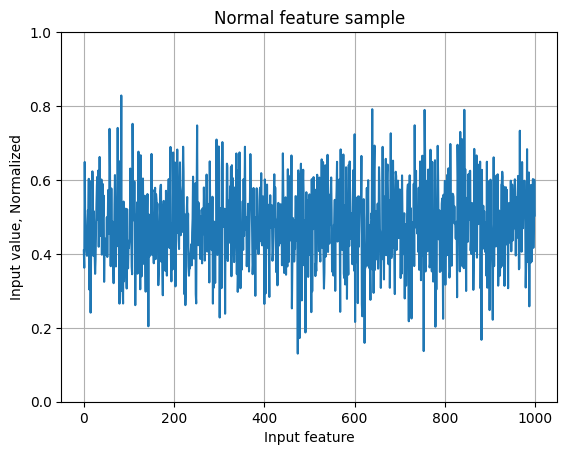

In [22]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(N_feature), normal_train_data[0])
plt.title("Normal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

Plot a abnomalous vibration feature

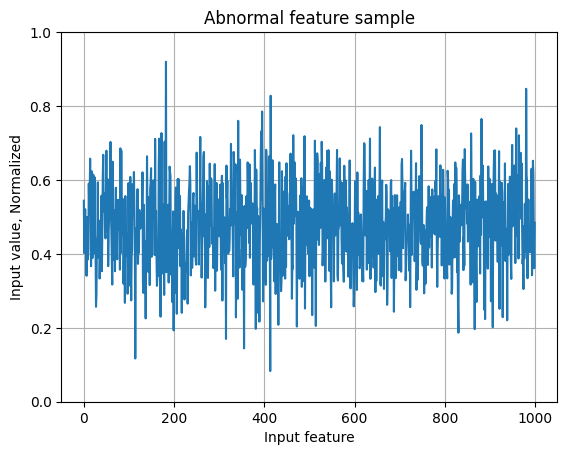

In [23]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(N_feature), anomalous_train_data[0])
plt.title("Abnormal feature sample")
plt.ylim([0, 1])
plt.xlabel("Input feature")
plt.ylabel("Input value, Normalized")
plt.show()

### Task 2.1

What differences do you notice between the normal and anomalous plots? Can you figure out anomaly based on the siganl/feature?



---

Compared to the normal signal, the anomalous signal exhibits a significantly higher amplitude (vibration intensity) and larger fluctuation range. While the normal plot remains relatively stable within a consistent range, the anomalous plot shows noticeable spike patterns and irregular variance over time.

---



### Autoencoder model training

Changing the size of the embedding (latent space) can produce interesting results. Try to play around with that layer size by assigning a value to the variable EMBEDDING_SIZE.

In [25]:
## Creating the artificial neural network using autoencoder
EMBEDDING_SIZE = 64  # Define how many neurons in the inner layer

import torch
import torch.nn as nn
import torch.optim as optim

class AnomalyDetector(nn.Module):
    def __init__(self):
        super(AnomalyDetector, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(N_feature, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, EMBEDDING_SIZE),
            nn.ReLU()
        )  # Smallest Layer Defined Here

        self.decoder = nn.Sequential(
            nn.Linear(EMBEDDING_SIZE, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, N_feature),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = AnomalyDetector()  # define autoencoder model class
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

# opt = optim.Adam(autoencoder.parameters(), lr=0.0001)  # default learning rate is 0.001, if you want, you can change learning rate.
# criterion = nn.L1Loss()

optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = nn.L1Loss()

Chosen Embedding Size:  64


### Training the model

Note that the autoencoder is trained using only the normal data, but is evaluated using the full test set.

In [26]:
# Training the model
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

train_dataset = TensorDataset(normal_train_data, normal_train_data)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

history = {
    "loss": [],
    "val_loss": []
}

num_epochs = 100

for epoch in range(num_epochs):
    autoencoder.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = autoencoder(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    autoencoder.eval()
    with torch.no_grad():
        val_input = test_data.to(device)
        val_output = autoencoder(val_input)
        val_loss = criterion(val_output, val_input).item()

    history["loss"].append(epoch_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - loss: {epoch_loss:.6f} - val_loss: {val_loss:.6f}")

Epoch [1/100] - loss: 0.091502 - val_loss: 0.091061
Epoch [2/100] - loss: 0.090749 - val_loss: 0.090522
Epoch [3/100] - loss: 0.090113 - val_loss: 0.090239
Epoch [4/100] - loss: 0.089718 - val_loss: 0.090097
Epoch [5/100] - loss: 0.089591 - val_loss: 0.090118
Epoch [6/100] - loss: 0.089563 - val_loss: 0.090093
Epoch [7/100] - loss: 0.089543 - val_loss: 0.090060
Epoch [8/100] - loss: 0.089528 - val_loss: 0.090089
Epoch [9/100] - loss: 0.089517 - val_loss: 0.090073
Epoch [10/100] - loss: 0.089508 - val_loss: 0.090067
Epoch [11/100] - loss: 0.089502 - val_loss: 0.090076
Epoch [12/100] - loss: 0.089495 - val_loss: 0.090060
Epoch [13/100] - loss: 0.089492 - val_loss: 0.090058
Epoch [14/100] - loss: 0.089486 - val_loss: 0.090080
Epoch [15/100] - loss: 0.089487 - val_loss: 0.090076
Epoch [16/100] - loss: 0.089484 - val_loss: 0.090062
Epoch [17/100] - loss: 0.089484 - val_loss: 0.090083
Epoch [18/100] - loss: 0.089483 - val_loss: 0.090084
Epoch [19/100] - loss: 0.089481 - val_loss: 0.090070
Ep

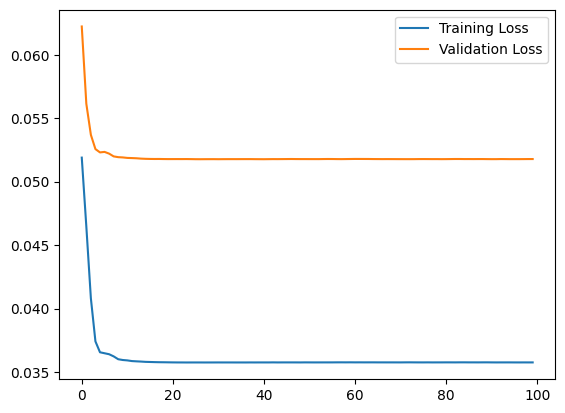

In [ ]:
# Plotting the evolution of training and validation loss
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

### Evaluation and determination of threshold

The Receiver Operating Characteristic (ROC) plots allows us to visualize the tradeoff between predicting anomalies as normal (false positives) and predicting normal data as an anomaly (false negative). Normal vibrations are labeled as 1 in this dataset but we have to flip them here to match the ROC curves expectations.

The ROC plot now has threshold values plotted on their corresponding points on the curve to aid in selecting a theshold for the application.

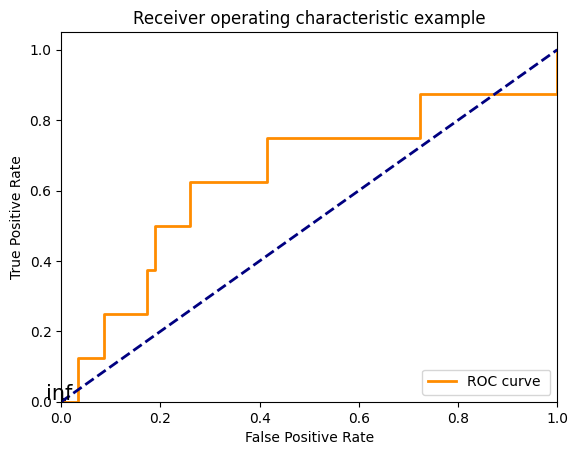

In [27]:
# Plotting True positive and false positive rate assessment
autoencoder.eval()

with torch.no_grad():
    reconstructions = autoencoder(test_data.to(device))
    loss = torch.mean(torch.abs(reconstructions - test_data.to(device)), dim=1)

loss = loss.cpu().numpy()
fpr = []
tpr = []

# the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1 - test_labels.cpu().numpy()

fpr, tpr, thresholds = roc_curve(flipped_labels, loss)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every = 20
thresholdsLength = len(thresholds)
colorMap = plt.get_cmap('jet', thresholdsLength)

for i in range(0, thresholdsLength, thresholds_every):
    threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
    plt.scatter(fpr[i], tpr[i], c='black')
    plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15})

plt.show()

In [28]:
roc_auc = auc(fpr, tpr) # check roc auc score (the area of roc graph above)
print("ROC - AUC score is {}.".format(roc_auc))

ROC - AUC score is 0.6400862068965518.


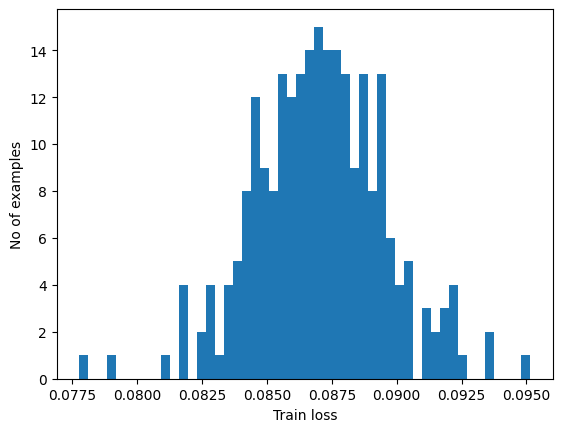

In [29]:
## reconstructions and histogram of training model
autoencoder.eval()

with torch.no_grad():
    reconstructions = autoencoder(normal_train_data.to(device))
    train_loss = torch.mean(torch.abs(reconstructions - normal_train_data.to(device)), dim=1)

train_loss = train_loss.cpu().numpy()

plt.hist(train_loss, bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

In [30]:
## Determining the threshold to detect anomalies
# threshold =  # If you want to assign a value labeled in black in the ROC graph
threshold = np.mean(train_loss) + np.std(train_loss)  # Common rule of thumb based on the histogram of the train loss
print("Threshold: ", threshold)  # You have to note the threshold you will use

def predict(model, data, threshold):
    model.eval()

    with torch.no_grad():
        data = data.to(device)
        reconstructions = model(data)
        loss = torch.mean(torch.abs(reconstructions - data), dim=1)
        predictions = loss < threshold

    return predictions.cpu().numpy(), loss.cpu().numpy()

def print_stats(predictions, labels):
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()

    print("Accuracy = {}".format(accuracy_score(labels, predictions)))
    print("Precision = {}".format(precision_score(labels, predictions)))
    print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Threshold:  0.08955925
Accuracy = 0.3787878787878788
Precision = 0.9047619047619048
Recall = 0.3275862068965517


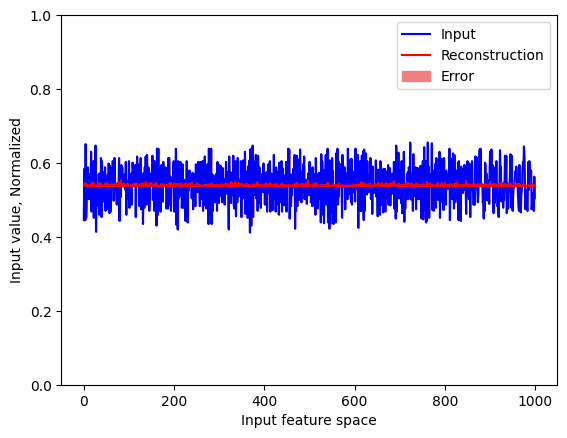

In [ ]:
# Plot "Normal" test data sample with reconstruction based on created model and error
autoencoder.eval()

with torch.no_grad():
    encoded_data = autoencoder.encoder(normal_test_data.to(device)).cpu().numpy()
    decoded_data = autoencoder.decoder(
        torch.tensor(encoded_data, dtype=torch.float32).to(device)
    ).cpu().numpy()

normal_sample = normal_test_data[0].cpu().numpy()

plt.plot(normal_sample, 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], normal_sample, color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()

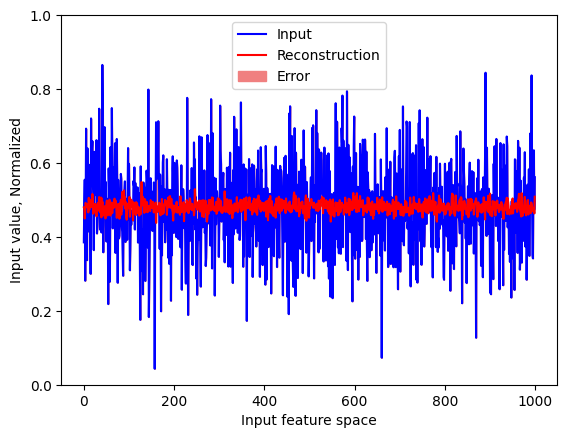

In [31]:
# Plot "Abnormal" test data sample with reconstruction based on created model and error
autoencoder.eval()

with torch.no_grad():
    decoded_data = autoencoder(anomalous_test_data.to(device)).cpu().numpy()

abnormal_sample = anomalous_test_data[0].cpu().numpy()

plt.plot(abnormal_sample, 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(N_feature), decoded_data[0], abnormal_sample, color='lightcoral')
plt.ylim([0, 1])
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.xlabel("Input feature space")
plt.ylabel("Input value, Normalized")
plt.show()

### Task 2.2

After finishing training the model so far in the condition below, answer the following questions.

  *   Acceleration axis: X-axis
  *   input feature: Raw data (without signal processing as Prelab8)
  *   Embedding size: 64
  *   Please specify if you change any hyper-parameters or variables.


1. What is performance of the model? Evaluate and analyze your model including Thresdhold, Accuracy, Precision, Recall, and so on. How did you determine the threshold?




---

Write down your answer here for Task 2.2, 1.

---



2. Do you think your model is good enough for anomaly detection of the AFF?



---

Write down your answer here for Task 2.2, 2.

---



### Save the model and reload it

After you train a model, you should save the model for implementation in the future.

In [41]:
# create the "models" folder first
import os
import datetime
import torch

model_folder = "models"
if not os.path.exists(model_folder):
    os.mkdir(model_folder)

t = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_identifier = "_lab8_anomaly_x-axis_raw"

# Saved model path
export_path = "./models/" + t + model_identifier + ".pth"

# save model state_dict
torch.save(autoencoder.state_dict(), export_path)

print("Model saved to:", export_path)

Model saved to: ./models/20260729_175550_lab8_anomaly_x-axis_raw.pth


After you save the model, you see the created model directory under 'models/' in your Colab session as in the example below.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_img1.png?raw=true" width="50%">


**If you run this Colab Notebook by mounting your Google Drive OR you run this on your laptop, you can skip this.**

Please note that if you want to reuse the saved model on different computer/platform, **YOU HAVE TO DOWNLOAD IT TO YOUR COMPUTER BEFORE YOU CLOSE THIS COLAB SESSION.** After you close/disconnect this Colab session, the saved model will be disappeared. Run the next code block to download the saved model as a zip file.

In [43]:
## First create a zip file for your saved model directory
## Note that your directory name must be different.
## after -r, the first arg. is the zip file, the second arg. is the target directory
!zip -r "/content/models/lab8_anomaly_x-axis_raw.zip" \
     "/content/models/lab8_anomaly_x-axis_raw.pth"

  adding: content/models/lab8_anomaly_x-axis_raw.pth (deflated 8%)


After you run the code block above, you see the created zip file from the saved model as the capture below. Try downloading it on your laptop.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_img2.png?raw=true" width="60%">

Before we wrap up this lab, let's reload the saved model to see if it works.

In [45]:
model_path = "/content/models/lab8_anomaly_x-axis_raw.pth"

try:
    loaded_model = AnomalyDetector()
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.to(device)
    loaded_model.eval()

    # simple forward pass to verify functionality
    with torch.no_grad():
        _ = loaded_model(torch.zeros((1, N_feature), dtype=torch.float32).to(device))

    print("Model reload success.\n")

    print("=== Model structure ===")
    print(loaded_model)

    print("\n=== Parameter summary ===")
    for name, param in loaded_model.named_parameters():
        print(f"{name}: shape={tuple(param.shape)}, requires_grad={param.requires_grad}")

    print("\n=== First few parameter values ===")
    for name, param in loaded_model.named_parameters():
        flat = param.detach().cpu().view(-1)
        print(f"{name}: {flat[:10].numpy()}")
        print("-" * 60)

except Exception as e:
    print("Model reload failed.")
    raise e

Model reload success.

=== Model structure ===
AnomalyDetector(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1000, bias=True)
    (5): Sigmoid()
  )
)

=== Parameter summary ===
encoder.0.weight: shape=(256, 1000), requires_grad=True
encoder.0.bias: shape=(256,), requires_grad=True
encoder.2.weight: shape=(128, 256), requires_grad=True
encoder.2.bias: shape=(128,), requires_grad=True
encoder.4.weight: shape=(64, 128), requires_grad=True
encoder.4.bias: shape=(64,), requires_grad=True
decoder.0.weight: shape=(128, 64), requires_grad=True
decoder.0.bia

### Task 2.3

After you perform reloading the saved model and run the code block above, the 'prediction' is a tuple that has two arrays. The first is boolean array and the second is float array. Explain these two arrays. For example, what do the elements in each array mean? Are they as expected?




---

The boolean array indicates whether each predicted condition is classified as normal (True) or abnormal (False), while the float array contains the corresponding raw probability scores output by the model, which aligns with expected binary classification outputs.

---



### Task 2.4

Discuss how to improve the model.



---

You can improve the model by extracting additional time- and frequency-domain features from the raw acceleration signals and optimizing the neural network architecture through hyperparameter tuning and regularization.

---



### Task 2.5

Model Unit 8 (prelab + lab) by creating a flow diagram that illustrates the logic, sequence, and processes of the unit.

---

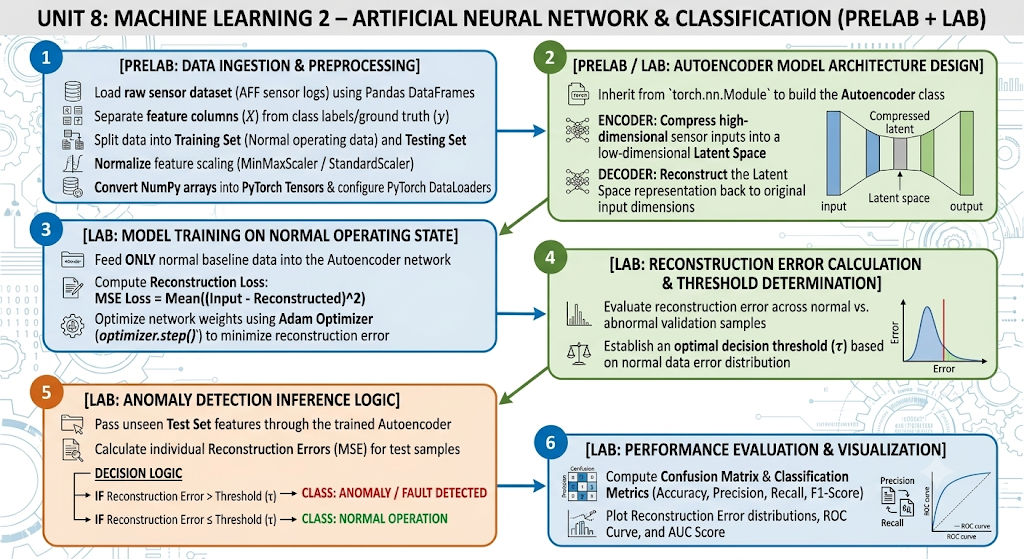

---

## Lab8 Summary and Deliverables

### Deliverable 1 (Do this at home)

Using the given training Python code, find your best model for anomaly detection of the AFF. As a short report including figures, tables, equations, and so on, justify how and why the best model is selected. You have to include the following information. If you need, add code/text blocks.

*   Hyper-parameters (Embedded size, batch size, epoch, etc.)
*   Threshold of your model and how determined it
*   What axis acceleration data is the best?
*   Which feature among raw, time domain, and frequency domain is the best?
*   Size of the feature
*   What are the prediction performances (accuracy, precision, recall)?



---

Data Composition & Target Classes
Dataset Size: 330 total samples evaluated across normal and abnormal machine operating states.

Target Classification: Binary label (Condition) distinguishing baseline "Normal" operation from "Abnormal" fault states.

Feature Analysis
Tri-Axial Acceleration Signals: Quantitative time-series readings captured across three spatial dimensions:

X-axis Acceleration (Xacc array [m/s2])

Y-axis Acceleration (Yacc array [m/s2])

Z-axis Acceleration (Zacc array [m/s2])

Signal & Statistical Processing Techniques
Statistical Distribution: Evaluated baseline central tendencies and variance across all three vibration axes to establish thresholds for healthy baseline behavior.

Frequency Domain Transformations: Applied Fast Fourier Transforms (scipy.fft) to convert raw time-series vibration signals into frequency spectra, identifying specific peak frequencies and harmonics associated with mechanical anomalies.

---



### Deliverable 2

Answer the following questions for your achievements

### Q1. Please summarize Lab8.

---

In Lab 8, I built and evaluated a PyTorch-based Autoencoder model to perform unsupervised anomaly detection on Advanced Feature Fluidics (AFF) sensor data using reconstruction error thresholds.

---


### Q2. What skills did you have to develop to accomplish this project?

---

I developed skills in feature engineering across time/frequency domains, configuring PyTorch Autoencoder architectures, and setting statistical decision thresholds for anomaly classification.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Understanding how an Autoencoder learns normal operating patterns to detect unseen anomalies via reconstruction loss was the most beneficial aspect for my learning.

---

### Q4. What challenges did you encounter in completing the project?

---

The main challenge was selecting the optimal feature domain and setting a precise threshold ($\tau$) that minimized false positives without missing true anomalies.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

 I overcome this by analyzing the statistical error distribution on normal validation data and comparing performance across different feature transformations to select the best configuration.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)